### In this file, we will learn about SimpleImputer, how to use it and parameters we can use this class to impute the missing values

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

- We will work on some specific columns of Titanic Data

In [75]:
# Import the dataset

df = pd.read_csv('titanic_toy.csv')

print(df.head())

    Age     Fare  Family  Survived
0  22.0   7.2500       1         0
1  38.0  71.2833       1         1
2  26.0   7.9250       0         1
3  35.0  53.1000       1         1
4  35.0   8.0500       0         0


In [76]:
# Let us check the Null percentage in each columns
print(df.isnull().mean()*100)

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64


In [77]:
X = df.iloc[:,:-1] # removing Survived column from Feature dataframe
y = df.iloc[:,-1] # Making a Series of Survived Data

### Filling the Nulls of Age and Fare column using SimpleImputer

In [78]:
from sklearn.impute import SimpleImputer

mean_impute = SimpleImputer(strategy = 'mean')
median_impute = SimpleImputer(strategy = 'median')

In [79]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state=0)

In [80]:
print(f"Shape X_train -> {X_train.shape}")
print(f"Shape X_test -> {X_test.shape}")
print(f"Shape y_train -> {y_train.shape}")
print(f"Shape y_test -> {y_test.shape}")

Shape X_train -> (712, 3)
Shape X_test -> (179, 3)
Shape y_train -> (712,)
Shape y_test -> (179,)


In [81]:
from sklearn.compose import ColumnTransformer

# Imputing Mean Values
preprocessor1 = ColumnTransformer(transformers=[
    ('mean_impute' , mean_impute , ['Age','Fare'])
])

# Imputing with Median Values
preprocessor2 = ColumnTransformer(transformers=[
    ('median_impute' , median_impute , ['Age','Fare'])
])

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV


pipe1 = Pipeline(steps=[
    ('preprocess' , preprocessor1),
    ('logReg' , LogisticRegressionCV(cv= 10 , scoring='accuracy',random_state=0))
])

pipe2 = Pipeline(steps=[
    ('preprocess' , preprocessor2),
    ('logReg' , LogisticRegressionCV(cv= 10 , scoring='accuracy',random_state=0))
])

pipe1.fit(X_train,y_train)
pipe2.fit(X_train,y_train)

y_pred_mean = pipe1.predict(X_test)
y_pred_median = pipe2.predict(X_test)

c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
c:\Users\Pradhuman\anaconda3\Lib\site-packages\

- We made two Models (i) Imputing Mean values to the Features and then training it and predicting the values
- (ii) Imputing Median Values to the Features and then training it and predicting the values

In [82]:
from sklearn.metrics import accuracy_score
print(f"Accuracy Score Mean Impute -> {accuracy_score(y_test , y_pred_mean)}")
print(f"Accuracy Score Median Impute -> {accuracy_score(y_test , y_pred_median)}")

Accuracy Score Mean Impute -> 0.6871508379888268
Accuracy Score Median Impute -> 0.6871508379888268


140     NaN
439    31.0
817    31.0
378    20.0
491    21.0
       ... 
835    39.0
192    19.0
629     NaN
559    36.0
684    60.0
Name: Age, Length: 712, dtype: float64

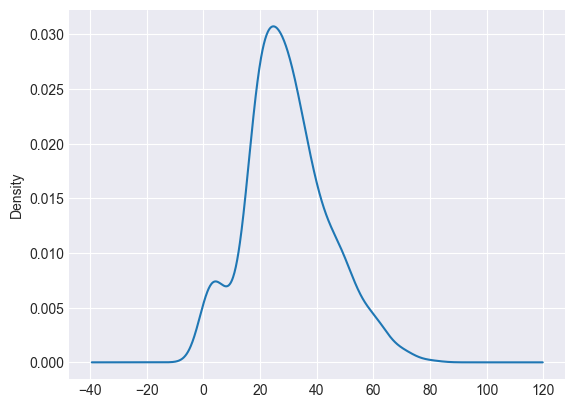

In [83]:
# Let us check the Distribution b/w original column and Imputed Column
X['Age'].plot.density()
X_train['Age']

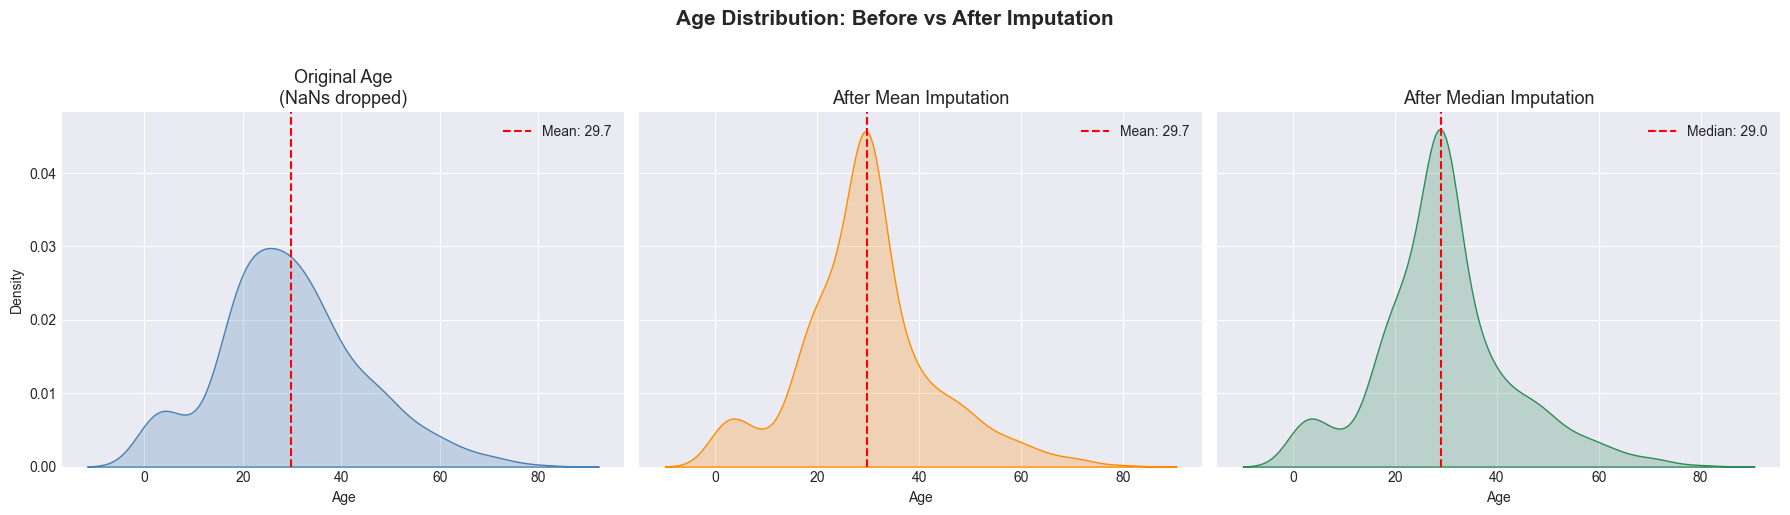

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 1. Original Age (with NaNs dropped for plotting) ──────────────────────────
age_original = X_train['Age'].dropna()

# ── 2. Get Mean-imputed Age ───────────────────────────────────────────────────
# fit on train, transform train (same logic as inside pipe1)
age_mean_imputed = mean_impute.fit_transform(X_train[['Age']])  # returns 2D array
age_mean_imputed = age_mean_imputed.flatten()                   # make 1D for plotting

# ── 3. Get Median-imputed Age ─────────────────────────────────────────────────
age_median_imputed = median_impute.fit_transform(X_train[['Age']])
age_median_imputed = age_median_imputed.flatten()

# ── 4. Plot all 3 KDEs ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

sns.kdeplot(age_original,        ax=axes[0], fill=True, color='steelblue')
axes[0].set_title('Original Age\n(NaNs dropped)', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].axvline(age_original.mean(), color='red', linestyle='--', label=f'Mean: {age_original.mean():.1f}')
axes[0].legend()

sns.kdeplot(age_mean_imputed,    ax=axes[1], fill=True, color='darkorange')
axes[1].set_title('After Mean Imputation', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].axvline(age_mean_imputed.mean(), color='red', linestyle='--', label=f'Mean: {age_mean_imputed.mean():.1f}')
axes[1].legend()

sns.kdeplot(age_median_imputed,  ax=axes[2], fill=True, color='seagreen')
axes[2].set_title('After Median Imputation', fontsize=13)
axes[2].set_xlabel('Age')
axes[2].axvline(np.median(age_median_imputed), color='red', linestyle='--', label=f'Median: {np.median(age_median_imputed):.1f}')
axes[2].legend()

plt.suptitle('Age Distribution: Before vs After Imputation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



### ***Large difference in the distribution In the Age column -> Thus we cannot apply Imputaion here***

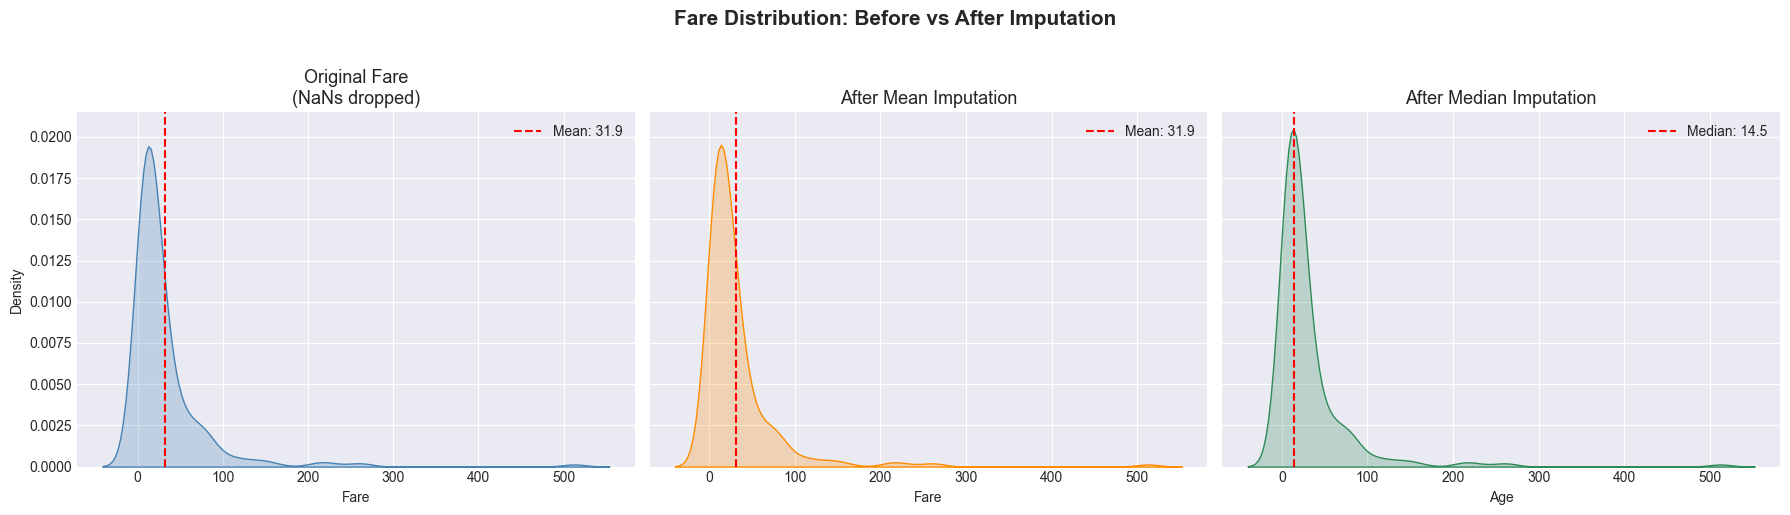

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 1. Original Age (with NaNs dropped for plotting) ──────────────────────────
fare_original = X_train['Fare'].dropna()

# ── 2. Get Mean-imputed Fare ───────────────────────────────────────────────────
# fit on train, transform train (same logic as inside pipe1)
fare_mean_imputed = mean_impute.fit_transform(X_train[['Fare']])  # returns 2D array
fare_mean_imputed = fare_mean_imputed.flatten()                   # make 1D for plotting

# ── 3. Get Median-imputed Fare ─────────────────────────────────────────────────
fare_median_imputed = median_impute.fit_transform(X_train[['Fare']])
fare_median_imputed = fare_median_imputed.flatten()

# ── 4. Plot all 3 KDEs ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

sns.kdeplot(fare_original,        ax=axes[0], fill=True, color='steelblue')
axes[0].set_title('Original Fare\n(NaNs dropped)', fontsize=13)
axes[0].set_xlabel('Fare')
axes[0].axvline(fare_original.mean(), color='red', linestyle='--', label=f'Mean: {fare_original.mean():.1f}')
axes[0].legend()

sns.kdeplot(fare_mean_imputed,    ax=axes[1], fill=True, color='darkorange')
axes[1].set_title('After Mean Imputation', fontsize=13)
axes[1].set_xlabel('Fare')
axes[1].axvline(fare_mean_imputed.mean(), color='red', linestyle='--', label=f'Mean: {fare_mean_imputed.mean():.1f}')
axes[1].legend()

sns.kdeplot(fare_median_imputed,  ax=axes[2], fill=True, color='seagreen')
axes[2].set_title('After Median Imputation', fontsize=13)
axes[2].set_xlabel('Age')
axes[2].axvline(np.median(fare_median_imputed), color='red', linestyle='--', label=f'Median: {np.median(fare_median_imputed):.1f}')
axes[2].legend()

plt.suptitle('Fare Distribution: Before vs After Imputation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



### ***No difference in the distribution In the fare column -> Thus we can apply Imputaion here***

### Let us check to fit the model without any nan values by just dropping them

In [86]:
new_df = df.dropna()

X = new_df.iloc[:,:-1]
y = new_df.iloc[:,-1]

In [87]:
X_train_dropped,X_test_dropped,y_train_dropped,y_test_dropped = train_test_split(X,y , test_size=.2 , random_state=41)

In [88]:
print(f'X_train -> {X_train.shape}')
print(f'X_test -> {X_train.shape}')

print(f'X_train -> {X_train_dropped.shape}')
print(f'X_test -> {X_train_dropped.shape}')



X_train -> (712, 3)
X_test -> (712, 3)
X_train -> (540, 3)
X_test -> (540, 3)


In [89]:
print(f"X_train -> {X_train_dropped.isnull().mean()*100}")
print(f"X_test -> {X_test_dropped.isnull().mean()*100}")

X_train -> Age       0.0
Fare      0.0
Family    0.0
dtype: float64
X_test -> Age       0.0
Fare      0.0
Family    0.0
dtype: float64


In [90]:
from sklearn.linear_model import LogisticRegressionCV
lr = LogisticRegressionCV(cv = 5 , scoring='accuracy')
lr.fit(X_train_dropped,y_train_dropped)

y_pred_dropped = lr.predict(X_test_dropped)

c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


In [93]:
# Comparing the Accuracy Scores
print(f"Accuracy Score Dropped-> {accuracy_score(y_test_dropped , y_pred_dropped)}")
print(f"Accuracy Score Mean-> {accuracy_score(y_test , y_pred_mean)}")
print(f"Accuracy Score Median-> {accuracy_score(y_test , y_pred_median)}")

Accuracy Score Dropped-> 0.6814814814814815
Accuracy Score Mean-> 0.6871508379888268
Accuracy Score Median-> 0.6871508379888268


### ***Conclusion***

- Learned simple_imputer and the advantages and disadvantages of it. 
- Did a small case study where I used complete production ready pipeline to impute the columns and fit the Logistic Regression model with 5 fold cv on it. 

- Checked the Accuracy score after both mean imputation and median imputation. Both were almost same 68%. 

- Also checked the difference in the distribution before and after imputaion.